In [1]:
import sys, tridecomp
print(sys.executable)
print(tridecomp.__file__)

/home/ramkumar/miniconda3/envs/tridecomp-py/bin/python
/home/ramkumar/Documents/my_projects/TriDecomp/TriDecomp/python/tridecomp/__init__.py


In [3]:
def genpoly(n,seed=42):
    np.random.seed(seed)
    # Generate n random angles
    angles = np.sort(np.random.rand(n) * 2 * np.pi)
    x=np.random.rand(n)+0.75
    # Generate points on a circle using the random angles
    points = np.array([(np.cos(angle)*y, np.sin(angle)*y) for (angle,y) in zip(angles,x)])
    return points
def plotT(tri,color='blue'):
    tri=np.vstack((tri,tri[0,:]))
    plt.plot(tri[:,0],tri[:,1],'x',color=color,linestyle='dashed')
    return

def plotGT(lg,lt,tcolor='black',gcolor='green',comment='no'):
    if comment=='yes':
        print('tri \n',lt)
        print('lines \n',lg)
    lt=np.vstack((lt,lt[0,:]))
    plt.plot(lt[:,0],lt[:,1],'x',color=tcolor,linestyle='dashed')
    for line in lg:
        lx,ly=line[0:3:2],line[1:4:2]
        plt.plot(lx,ly,'x',color=gcolor,linestyle='solid')
    return

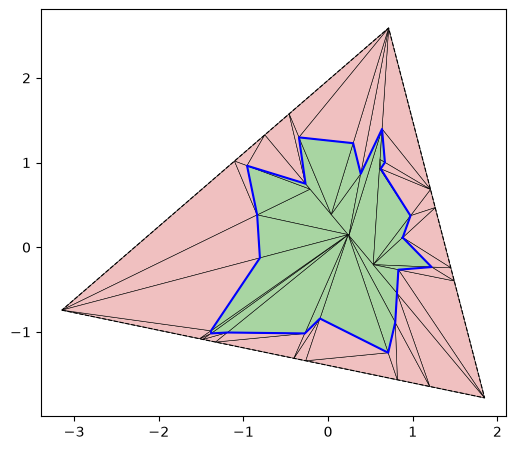

In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from tridecomp import tessellate, edges_of, gettri, walk, tiles, UNMARKED, INSIDE, OUTSIDE

# p = np.array([[0, 0], [1, 0], [1, 1], [0, 1]], float)
p=genpoly(21,42)
t = gettri(p, 1.5)
events = tessellate(edges_of(p), t)
w = walk(events, t, p)
colors = {UNMARKED: "#ddd", INSIDE: "#a8d5a2", OUTSIDE: "#f0c0c0"}

fig, ax = plt.subplots(figsize=(6, 6))
for tid, tri in w["tiles"].items():
    c = np.vstack([tri, tri[0]])
    ax.fill(c[:, 0], c[:, 1], facecolor=colors[w["marks"][tid]], edgecolor="k", lw=0.4)
ax.plot(*np.vstack([p, p[0]]).T, "b-", lw=1.5)   # cycle
ax.plot(*np.vstack([t, t[0]]).T, "k--", lw=0.8)  # enclosing triangle
ax.set_aspect("equal")